# Pré Processamento e Feature Engineering

Este notebook representa o ensaio que foi realizado para a construção do arquivo de limpeza e tratamento dos dados a serem processados.

In [2]:
import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings

plt.style.use('ggplot')
sns.set_style(style='whitegrid')
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')
load_dotenv()

True

In [3]:
dir = os.getenv("DATA_PATH")

df_transaction = pd.read_csv(fr'{dir}\train_transaction.csv')
df_identity = pd.read_csv(rf'{dir}\train_identity.csv')

## Mesclando os Dados de Transações e Identidade

In [4]:
df_full = df_transaction.merge(df_identity, on='TransactionID', how='left')

In [5]:
df_full

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.50,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,117.000000,0.000000,0.0,0.000000,0.0,0.0,117.0,0.0,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,117.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,117.0,0.0,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.00,W,2755,404.0,150.0

## Análise de Valores Ausentes

Número de colunas com valores ausentes: 414


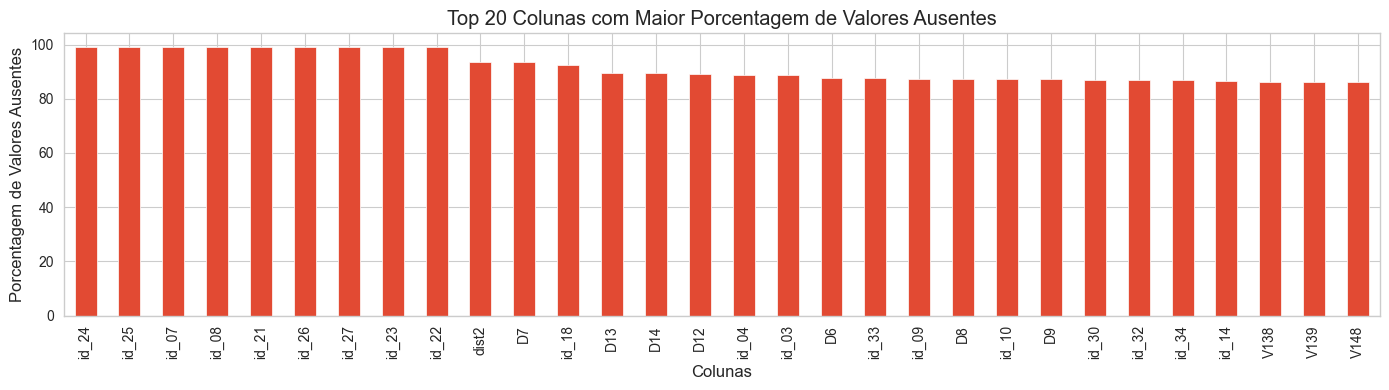

In [6]:
# Calculando a porcentagem de valores ausentes em cada coluna
missing_values = df_full.isnull().mean().sort_values(ascending=False) * 100

# Filtrando apenas colunas com valores ausentes
missing_values = missing_values[missing_values > 0]

print(f'Número de colunas com valores ausentes: {len(missing_values)}')

# Visualizando as 20 colunas com maior porcentagem de valores ausentes
plt.figure(figsize=(14, 4))
missing_values[:30].plot(kind='bar')
plt.title('Top 20 Colunas com Maior Porcentagem de Valores Ausentes')
plt.xlabel('Colunas')
plt.ylabel('Porcentagem de Valores Ausentes')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Tratamento de Valores Ausentes

Definir estratégias para tratar os valores ausentes em diferentes tipos de colunas.

In [7]:
# Identificando colunas numéricas e categóricas
numeric_cols = df_full.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df_full.select_dtypes(include=['object']).columns.tolist()

# Removendo colunas de ID e a variável alvo das listas
cols_to_remove = ['TransactionID', 'isFraud']
numeric_cols = [col for col in numeric_cols if col not in cols_to_remove]

print(f'Número de colunas numéricas: {len(numeric_cols)}')
print(f'Número de colunas categóricas: {len(categorical_cols)}')

Número de colunas numéricas: 401
Número de colunas categóricas: 31


# Definindo estratégias para tratamento de valores ausentes

In [8]:
# Para colunas numéricas com menos de 30% de valores ausentes, usaremos a mediana
numeric_cols_median = [col for col in numeric_cols if df_full[col].isnull().mean() < 0.3]

# Para colunas numéricas com 30% ou mais de valores ausentes, usaremos um valor especial (-999)
numeric_cols_constant = [col for col in numeric_cols if df_full[col].isnull().mean() >= 0.3]

# Para colunas categóricas, usaremos o valor mais frequente
categorical_cols_mode = [col for col in categorical_cols if df_full[col].isnull().mean() < 0.3]

# Para colunas categóricas com 30% ou mais de valores ausentes, usaremos 'unknown'
categorical_cols_constant = [col for col in categorical_cols if df_full[col].isnull().mean() >= 0.3]

print(f'Colunas numéricas a serem preenchidas com mediana: {len(numeric_cols_median)}')
print(f'Colunas numéricas a serem preenchidas com constante: {len(numeric_cols_constant)}')
print(f'Colunas categóricas a serem preenchidas com moda: {len(categorical_cols_mode)}')
print(f'Colunas categóricas a serem preenchidas com "unknown": {len(categorical_cols_constant)}')

Colunas numéricas a serem preenchidas com mediana: 195
Colunas numéricas a serem preenchidas com constante: 206
Colunas categóricas a serem preenchidas com moda: 5
Colunas categóricas a serem preenchidas com "unknown": 26


In [9]:
# Aplicando as estratégias de tratamento de valores ausentes

# Criando uma cópia do DataFrame para não modificar o original
df_processed = df_full.copy()

# Preenchendo valores ausentes em colunas numéricas com mediana
for col in numeric_cols_median:
    df_processed[col].fillna(df_processed[col].median(), inplace=True)

# Preenchendo valores ausentes em colunas numéricas com constante (-999)
for col in numeric_cols_constant:
    df_processed[col].fillna(-999, inplace=True)

# Preenchendo valores ausentes em colunas categóricas com moda
for col in categorical_cols_mode:
    df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)

# Preenchendo valores ausentes em colunas categóricas com 'unknown'

for col in categorical_cols_constant:
    df_processed[col].fillna('unknown', inplace=True)

# Verificando se ainda existem valores ausentes
missing_after = df_processed.isnull().sum().sum()
print(f'Número total de valores ausentes após tratamento: {missing_after}')

Número total de valores ausentes após tratamento: 0


## Engenharia de Features

Criar novas features úteis

In [10]:
# Convertendo TransactionDT para features temporais

# Dia da semana (0-6, onde 0 é segunda-feira)
df_processed['TransactionDay'] = df_processed['TransactionDT'] // (24 * 60 * 60)
df_processed['TransactionDayOfWeek'] = df_processed['TransactionDay'] % 7

# Hora do dia (0-23)
df_processed['TransactionHour'] = (df_processed['TransactionDT'] % (24 * 60 * 60)) // 3600

# Parte do dia (manhã, tarde, noite, madrugada)
df_processed['TransactionPartOfDay'] = pd.cut(
    df_processed['TransactionHour'],
    bins=[0, 6, 12, 18, 24],
    labels=['Madrugada', 'Manhã', 'Tarde', 'Noite']
)

# Fim de semana ou dia útil
df_processed['TransactionIsWeekend'] = df_processed['TransactionDayOfWeek'].isin([5, 6]).astype(int)

print('Features temporais criadas:')
for col in ['TransactionDay', 'TransactionDayOfWeek', 'TransactionHour', 'TransactionPartOfDay', 'TransactionIsWeekend']:
    print(f'- {col}')

Features temporais criadas:
- TransactionDay
- TransactionDayOfWeek
- TransactionHour
- TransactionPartOfDay
- TransactionIsWeekend


In [11]:
# Extraindo a parte decimal do valor da transação (centavos)
df_processed['TransactionAmt_decimal'] = df_processed['TransactionAmt'] - df_processed['TransactionAmt'].astype(int)

# Criando faixas de valor da transação
df_processed['TransactionAmt_bin'] = pd.qcut(
    df_processed['TransactionAmt'],
    q=10,
    labels=False,
    duplicates='drop'
)

print('Features de valor criadas:')
for col in ['TransactionAmt_decimal', 'TransactionAmt_bin']:
    print(f'- {col}')

Features de valor criadas:
- TransactionAmt_decimal
- TransactionAmt_bin


In [12]:
# Criando features de agregação para cartões

# Número de transações por cartão
card_counts = df_processed.groupby('card1')['TransactionID'].count().reset_index()
card_counts.columns = ['card1', 'card1_count']
df_processed = df_processed.merge(card_counts, on='card1', how='left')

# Valor médio de transação por cartão
card_amounts = df_processed.groupby('card1')['TransactionAmt'].mean().reset_index()
card_amounts.columns = ['card1', 'card1_avg_amount']
df_processed = df_processed.merge(card_amounts, on='card1', how='left')

print('Features de agregação para cartões criadas:')
for col in ['card1_count', 'card1_avg_amount']:
    print(f'- {col}')

Features de agregação para cartões criadas:
- card1_count
- card1_avg_amount


In [13]:
# Criando features para domínios de email

# Extraindo o provedor de email (gmail, hotmail, yahoo, etc.)
df_processed['P_emaildomain_provider'] = df_processed['P_emaildomain'].str.split('.').str[0]

# Verificando se os domínios de email do comprador e do destinatário são iguais
if 'R_emaildomain' in df_processed.columns:
    df_processed['email_match'] = (df_processed['P_emaildomain'] == df_processed['R_emaildomain']).astype(int)

print('Features de email criadas:')
print('- P_emaildomain_provider')
if 'R_emaildomain' in df_processed.columns:
    print('- email_match')

Features de email criadas:
- P_emaildomain_provider
- email_match


In [14]:
# Criando features para dispositivos
# Extraindo a marca do dispositivo (primeiro termo antes de espaço ou caractere especial)
df_processed['DeviceBrand'] = df_processed['DeviceInfo'].str.split(r'[\s/:;\-_,\.\\]', expand=True)[0]

print('Features de dispositivo criadas:')
print('- DeviceBrand')

Features de dispositivo criadas:
- DeviceBrand


## Codificação de Variáveis Categóricas

Tratando variáveis categóricas para que possam ser utilizadas pelos modelos de machine learning.

In [15]:
# Identificando colunas categóricas após a engenharia de features
categorical_cols = df_processed.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Número de colunas categóricas após engenharia de features: {len(categorical_cols)}')
print(f'Colunas categóricas: {categorical_cols}')

Número de colunas categóricas após engenharia de features: 34
Colunas categóricas: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo', 'TransactionPartOfDay', 'P_emaildomain_provider', 'DeviceBrand']


In [16]:
# Separando colunas categóricas com poucos valores únicos (para one-hot encoding)
# e colunas com muitos valores únicos (para label encoding)
categorical_cols_few = []
categorical_cols_many = []

for col in categorical_cols:
    if df_processed[col].nunique() < 10:  # Limite arbitrário de 10 valores únicos
        categorical_cols_few.append(col)
    else:
        categorical_cols_many.append(col)

print(f'Colunas para one-hot encoding (poucos valores únicos): {len(categorical_cols_few)}')
print(f'Colunas para label encoding (muitos valores únicos): {len(categorical_cols_many)}')

Colunas para one-hot encoding (poucos valores únicos): 26
Colunas para label encoding (muitos valores únicos): 8


In [17]:
# Aplicando Target Encoding para ProductCD

# Calculando a taxa média de fraude por categoria de ProductCD
product_fraud_rate = df_processed.groupby('ProductCD')['isFraud'].mean().to_dict()

# Aplicando o encoding
df_processed['ProductCD_target_enc'] = df_processed['ProductCD'].map(product_fraud_rate)

print('Target Encoding aplicado para ProductCD')

Target Encoding aplicado para ProductCD


In [ ]:
# Aplicando One-Hot Encoding para colunas com poucos valores únicos
df_encoded = pd.get_dummies(df_processed, columns=categorical_cols_few, drop_first=False)

# Aplicando Label Encoding para colunas com muitos valores únicos
label_encoders = {}
for col in categorical_cols_many:
    le = LabelEncoder()
    df_encoded[col + '_encoded'] = le.fit_transform(df_processed[col])
    label_encoders[col] = le
    
# Removendo as colunas categóricas originais que foram codificadas com Label Encoding


print(f'Dimensões após codificação: {df_encoded.shape}')

Dimensões após codificação: (590540, 516)


In [35]:
df_encoded

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_13,id_14,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_30,id_31,id_32,id_33,DeviceInfo,TransactionDay,TransactionDayOfWeek,TransactionHour,TransactionIsWeekend,TransactionAmt_decimal,TransactionAmt_bin,card1_count,card1_avg_amount,P_emaildomain_provider,email_match,DeviceBrand,ProductCD_target_enc,ProductCD_C,ProductCD_H,ProductCD_R,ProductCD_S,ProductCD_W,card4_american express,card4_discover,card4_mastercard,card4_visa,card6_charge card,card6_credit,card6_debit,card6_debit or credit,M1_F,M1_T,M1_unknown,M2_F,M2_T,M2_unknown,M3_F,M3_T,M3_unknown,M4_M0,M4_M1,M4_M2,M4_unknown,M5_F,M5_T,M5_unknown,M6_F,M6_T,M7_F,M7_T,M7_unknown,M8_F,M8_T,M8_unknown,M9_F,M9_T,M9_unknown,id_12_Found,id_12_NotFound,id_12_unknown,id_15_Found,id_15_New,id_15_Unknown,id_15_unknown,id_16_Found,id_16_NotFound,id_16_unknown,id_23_IP_PROXY:ANONYMOUS,id_23_IP_PROXY:HIDDEN,id_23_IP_PROXY:TRANSPARENT,id_23_unknown,id_27_Found,id_27_NotFound,id_27_unknown,id_28_Found,id_28_New,id_28_unknown,id_29_Found,id_29_NotFound,id_29_unknown,id_34_match_status:-1,id_34_match_status:0,id_34_match_status:1,id_34_match_status:2,id_34_unknown,id_35_F,id_35_T,id_35_unknown,id_36_F,id_36_T,id_36_unknown,id_37_F,id_37_T,id_37_unknown,id_38_F,id_38_T,id_38_unknown,DeviceType_desktop,DeviceType_mobile,DeviceType_unknown,TransactionPartOfDay_Madrugada,TransactionPartOfDay_Manhã,TransactionPartOfDay_Tarde,TransactionPartOfDay_Noite,P_emaildomain_encoded,R_emaildomain_encoded,id_30_encoded,id_31_encoded,id_33_encoded,DeviceInfo_encoded,P_emaildomain_provider_encoded,DeviceBrand_encoded
0,2987000,0,86400,68.50,13926,361.0,150.0,142.0,315.0,87.0,19.0,-999.0,gmail.com,unknown,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,-999.0,13.0,26.0,-999.0,-999.0,-999.0,-999.0,-999.0,13.0,13.0,-999.0,-999.0,-999.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0

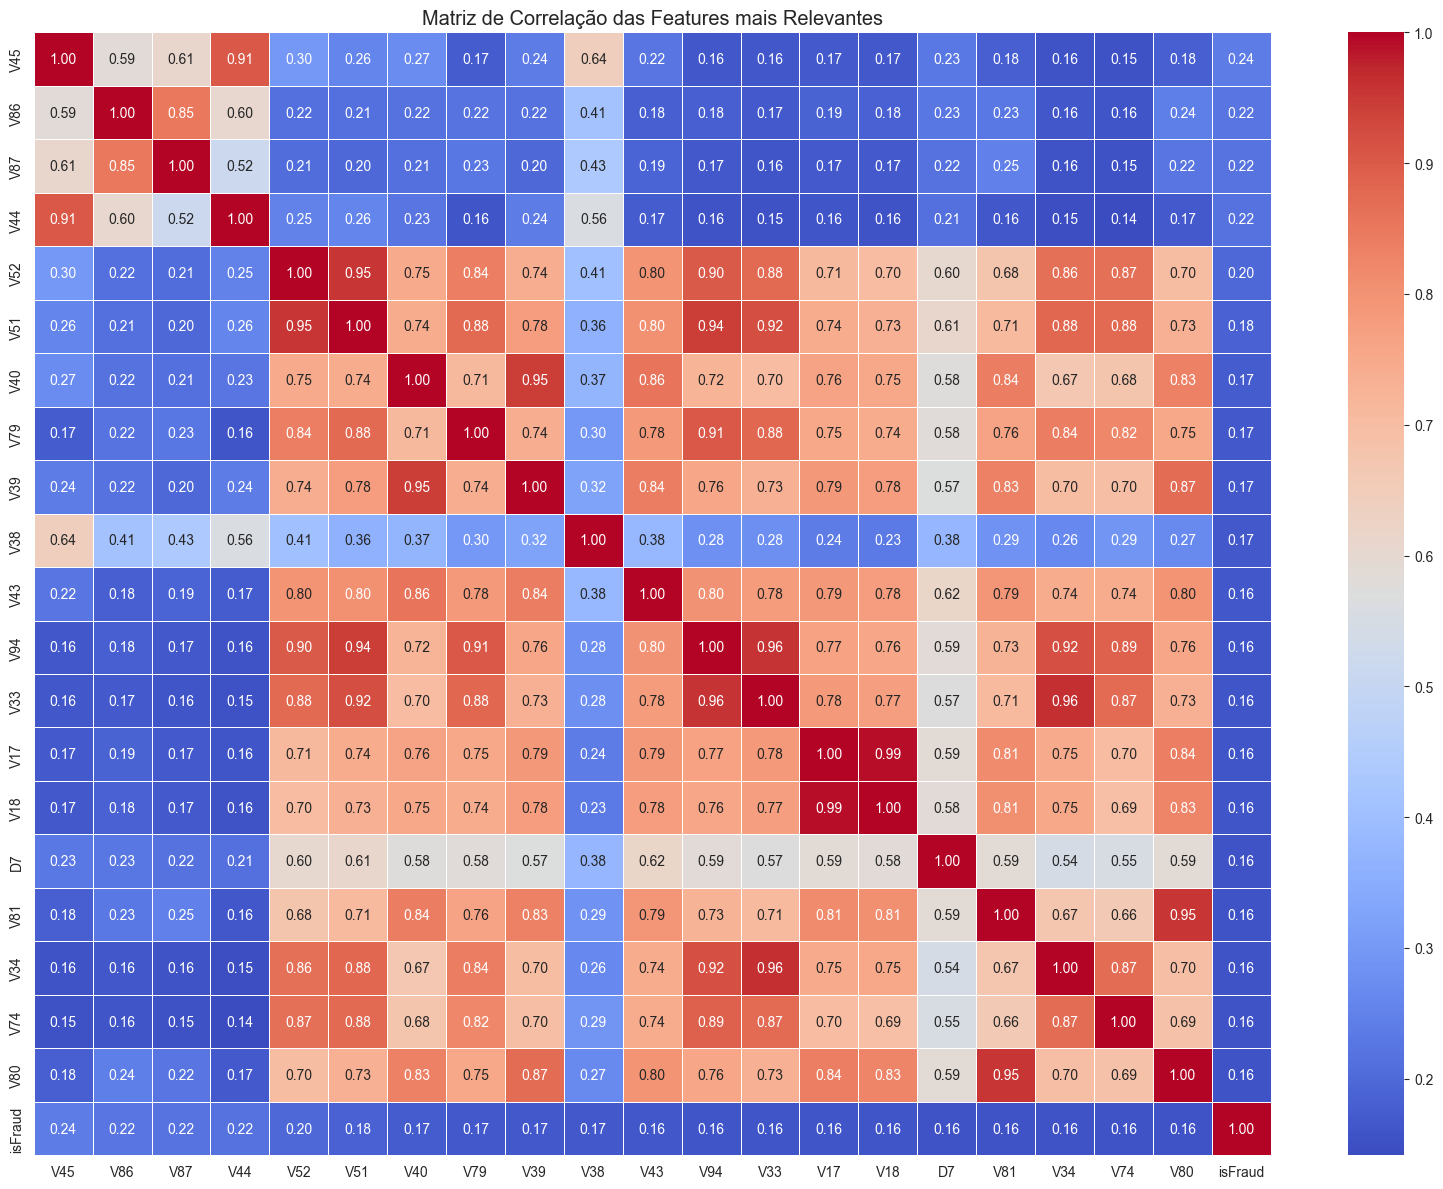

In [41]:
# Visualizando a matriz de correlação
# Selecionando as 20 features mais correlacionadas com isFraud
if 'isFraud' not in numeric_cols:
    numeric_cols.append('isFraud')
corr_matrix = df_encoded[numeric_cols].corr()
target_corr = corr_matrix['isFraud'].sort_values(ascending=False)
top_corr_features = target_corr.abs().sort_values(ascending=False)[1:21].index.tolist()
top_corr_features.append('isFraud')  # Adicionando a variável alvo


# Criando a matriz de correlação para as features selecionadas
plt.figure(figsize=(16, 12))
sns.heatmap(df_encoded[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação das Features mais Relevantes')
plt.tight_layout()
plt.show()

In [42]:
df_encoded = df_encoded.drop(columns=categorical_cols_many)

## Divisão dos Dados em Treino e Validação

dividir os dados em conjuntos de treino e validação, considerando a natureza temporal dos dados.

In [19]:
# Separando features e target
X = df_encoded.drop(columns=['isFraud', 'TransactionID'])
y = df_encoded['isFraud']

print(f'Dimensões de X: {X.shape}')
print(f'Dimensões de y: {y.shape}')

Dimensões de X: (590540, 506)
Dimensões de y: (590540,)


In [20]:
# Usando TimeSeriesSplit para divisão temporal dos dados
tscv = TimeSeriesSplit(n_splits=5)

# Ordenando os dados por TransactionDT
if 'TransactionDT' in X.columns:
    sorted_indices = X['TransactionDT'].argsort()
    X = X.iloc[sorted_indices]
    y = y.iloc[sorted_indices]

# Obtendo o último split para treino e validação
for train_index, val_index in tscv.split(X):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

print(f'Dimensões de X_train: {X_train.shape}')
print(f'Dimensões de X_val: {X_val.shape}')
print(f'Dimensões de y_train: {y_train.shape}')
print(f'Dimensões de y_val: {y_val.shape}')

Dimensões de X_train: (492117, 506)
Dimensões de X_val: (98423, 506)
Dimensões de y_train: (492117,)
Dimensões de y_val: (98423,)


In [21]:
# Verificando a distribuição da variável alvo nos conjuntos de treino e validação
print(f'Distribuição de classes no conjunto de treino:\n{y_train.value_counts(normalize=True) * 100}')
print(f'\nDistribuição de classes no conjunto de validação:\n{y_val.value_counts(normalize=True) * 100}')

Distribuição de classes no conjunto de treino:
isFraud
0    96.491485
1     3.508515
Name: proportion, dtype: float64

Distribuição de classes no conjunto de validação:
isFraud
0    96.548571
1     3.451429
Name: proportion, dtype: float64


## Balanceamento de Classes

Aplicar técnicas de balanceamento de classes para lidar com o desbalanceamento extremo dos dados.

In [22]:
# Aplicando SMOTE para balancear as classes no conjunto de treino
# Usamos uma taxa de amostragem menor que 1 para não criar tantos exemplos sintéticos
smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f'Dimensões de X_train após SMOTE: {X_train_resampled.shape}')
print(f'Dimensões de y_train após SMOTE: {y_train_resampled.shape}')
print(f'Distribuição de classes após SMOTE:\n{y_train_resampled.value_counts(normalize=True) * 100}')

Dimensões de X_train após SMOTE: (522336, 506)
Dimensões de y_train após SMOTE: (522336,)
Distribuição de classes após SMOTE:
isFraud
0    90.909108
1     9.090892
Name: proportion, dtype: float64


## Salvando os Dados Pré-processados

Salvar os dados pré-processados para uso posterior no treinamento do modelo.

In [23]:
# Salvando os conjuntos de dados pré-processados
X_train_resampled.to_csv(rf'{dir}\X_train_processed.csv', index=False)
y_train_resampled.to_csv(rf'{dir}\y_train_processed.csv', index=False)
X_val.to_csv(rf'{dir}\X_val_processed.csv', index=False)
y_val.to_csv(rf'{dir}\y_val_processed.csv', index=False)

print('Dados pré-processados salvos com sucesso!')

Dados pré-processados salvos com sucesso!


In [24]:
y_train_resampled.head(5)

0    0
1    0
2    0
3    0
4    0
Name: isFraud, dtype: int64

In [25]:
X_train_resampled.head(5)

,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,dist1,dist2,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_13,id_14,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32,TransactionDay,TransactionDayOfWeek,TransactionHour,TransactionIsWeekend,TransactionAmt_decimal,TransactionAmt_bin,card1_count,card1_avg_amount,email_match,ProductCD_target_enc,ProductCD_C,ProductCD_H,ProductCD_R,ProductCD_S,ProductCD_W,card4_american express,card4_discover,card4_mastercard,card4_visa,card6_charge card,card6_credit,card6_debit,card6_debit or credit,M1_F,M1_T,M1_unknown,M2_F,M2_T,M2_unknown,M3_F,M3_T,M3_unknown,M4_M0,M4_M1,M4_M2,M4_unknown,M5_F,M5_T,M5_unknown,M6_F,M6_T,M7_F,M7_T,M7_unknown,M8_F,M8_T,M8_unknown,M9_F,M9_T,M9_unknown,id_12_Found,id_12_NotFound,id_12_unknown,id_15_Found,id_15_New,id_15_Unknown,id_15_unknown,id_16_Found,id_16_NotFound,id_16_unknown,id_23_IP_PROXY:ANONYMOUS,id_23_IP_PROXY:HIDDEN,id_23_IP_PROXY:TRANSPARENT,id_23_unknown,id_27_Found,id_27_NotFound,id_27_unknown,id_28_Found,id_28_New,id_28_unknown,id_29_Found,id_29_NotFound,id_29_unknown,id_34_match_status:-1,id_34_match_status:0,id_34_match_status:1,id_34_match_status:2,id_34_unknown,id_35_F,id_35_T,id_35_unknown,id_36_F,id_36_T,id_36_unknown,id_37_F,id_37_T,id_37_unknown,id_38_F,id_38_T,id_38_unknown,DeviceType_desktop,DeviceType_mobile,DeviceType_unknown,TransactionPartOfDay_Madrugada,TransactionPartOfDay_Manhã,TransactionPartOfDay_Tarde,TransactionPartOfDay_Noite,P_emaildomain_encoded,R_emaildomain_encoded,id_30_encoded,id_31_encoded,id_33_encoded,DeviceInfo_encoded,P_emaildomain_provider_encoded,DeviceBrand_encoded
0,86400,68.5,13926,361.0,150.0,142.0,315.0,87.0,19.0,-999.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,-999.0,13.0,26.0,-999.0,-999.0,-999.0,-999.0,-999.0,13.0,13.0,-999.0,-999.0,-999.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,

## Conclusões do Pré-processamento

Neste notebook, realizamos as seguintes etapas de pré-processamento dos dados:

1. **Tratamento de Valores Ausentes**: Aplicamos diferentes estratégias para preencher valores ausentes em colunas numéricas e categóricas.

2. **Engenharia de Features**: Criamos novas features a partir dos dados existentes, incluindo features temporais, features de valor da transação, features de agregação para cartões e features para domínios de email e dispositivos.

3. **Codificação de Variáveis Categóricas**: Aplicamos One-Hot Encoding para colunas categóricas com poucos valores únicos e Label Encoding para colunas com muitos valores únicos. Também aplicamos Target Encoding para a coluna ProductCD.

4. **Divisão dos Dados**: Dividimos os dados em conjuntos de treino e validação, considerando a natureza temporal dos dados.

5. **Balanceamento de Classes**: Aplicamos SMOTE para lidar com o desbalanceamento extremo dos dados.

Os dados pré-processados estão prontos para serem utilizados no treinamento de modelos de machine learning para detecção de fraudes.